- MNIST数据集是图像分类中广泛使用的数据集之一，但作为基准数据集过于简单。我们将使用类似但更复杂的Fashion-MNIST数据集

In [1]:
%matplotlib inline
import torch 
import torchvision
from torch.utils import data  #方便读取数据
from torchvision import transforms #pytorch中图像预处理的工具包
from d2l import torch as d2l

d2l.use_svg_display()

- 通过框架中的内置函数将Fashion-MNIST数据集下载到本地并加载到内存中。

In [2]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0～1之间
trans = transforms.ToTensor() 
# 下载数据集并加载到内存中
# 训练数据集
mnist_train = torchvision.datasets.FashionMNIST(root="../data", train=True, transform=trans, download=True)
# 测试数据集
mnist_test = torchvision.datasets.FashionMNIST(root="../data", train=False, transform=trans, download=True)
len(mnist_train), len(mnist_test)

#数据去github下载，代码下载会超时

(60000, 10000)

In [3]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [4]:
def get_fashion_mnist_labels(labels): 
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale) #初始化画布大小
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize) # 返回画布和子画布上的坐标轴对象
    axes = axes.flatten() #将多维数组展平为一维数组，方便迭代
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy()) #要显示图像，必须先将它们转成numpy格式
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False) #不要显示坐标轴
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    # return axes #避免下面的plt.show()重复显示图像

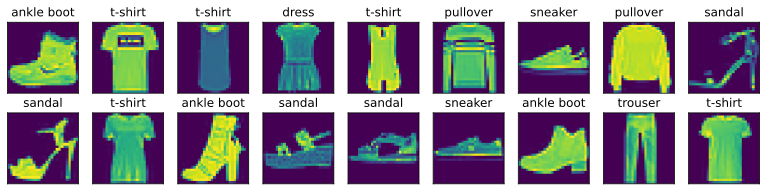

In [5]:
x,y = next(iter(data.DataLoader(mnist_train,batch_size=18)))
show_images(x.reshape(18,28,28),2,9,titles=get_fashion_mnist_labels(y))
d2l.plt.show()

- 读取一小批量数据,大小为batch_size

In [8]:
batch_size = 256

def get_dataloader_workers(): 
    """使用4个进程来读取数据"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

timer = d2l.Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'4.26 sec'

- 定义load_data_fashion_mnist函数

In [10]:
#在这里写这个函数是为了方便后续使用，直接调用这个函数就可以了，不需要每次都写一大段代码来加载数据集
def load_data_fashion_mnist(batch_size, resize=None):  
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    dataset = gluon.data.vision
    trans = [dataset.transforms.ToTensor()]
    if resize:
        trans.insert(0, dataset.transforms.Resize(resize))
    trans = dataset.transforms.Compose(trans)
    mnist_train = dataset.FashionMNIST(train=True).transform_first(trans)
    mnist_test = dataset.FashionMNIST(train=False).transform_first(trans)
    return (gluon.data.DataLoader(mnist_train, batch_size, shuffle=True,
                                  num_workers=get_dataloader_workers()),
            gluon.data.DataLoader(mnist_test, batch_size, shuffle=False,
                                  num_workers=get_dataloader_workers()))